# Checkpoint 5 – Statistical Computing with Python

## Parte 1 – Análise estatística do dataset WINES

**Objetivo:** realizar uma análise exploratória utilizando duas variáveis quantitativas do dataset: `Alcohol` e `Malic_Acid`.

A análise foi dividida em:
1. Visualização dos dados;
2. Análise descritiva;
3. Análise probabilística.

Os cálculos foram feitos a partir dos 178 registros do arquivo `wine-clustering.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("wine-clustering.csv")

print("Quantidade de linhas e colunas:", df.shape)
df.head()


Quantidade de linhas e colunas: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### Observação inicial

O dataset possui **178 registros e 13 variáveis**. Para esta parte do checkpoint foram escolhidas duas variáveis quantitativas:

- **Alcohol:** teor alcoólico do vinho.
- **Malic_Acid:** quantidade de ácido málico.

A escolha foi feita porque são variáveis numéricas e permitem calcular as medidas estatísticas.


## 1. Teor alcoólico (`Alcohol`)

### 1.1 Tabela de distribuição de frequências

In [2]:
# Intervalos e frequências (os mesmos limites são usados no histograma)
contagens, limites = np.histogram(df["Alcohol"], bins=5)
rotulos = [f"{limites[i]:.2f} a {limites[i+1]:.2f}" for i in range(5)]
tabela_frequencia = pd.DataFrame({
    "Intervalo": rotulos,
    "Frequência": contagens,
    "Frequência relativa (%)": (contagens / len(df) * 100).round(2)
})

tabela_frequencia


,Intervalo,Frequência,Frequência relativa (%)
0,11.03 a 11.79,11,6.18
1,11.79 a 12.55,50,28.09
2,12.55 a 13.31,48,26.97
3,13.31 a 14.07,50,28.09
4,14.07 a 14.83,19,10.67


**Interpretação:** as classes de 11,79 a 12,55 e de 13,31 a 14,07 têm a maior frequência (28,09% cada), seguidas de perto pela classe central (26,97%). Os extremos concentram poucos vinhos.

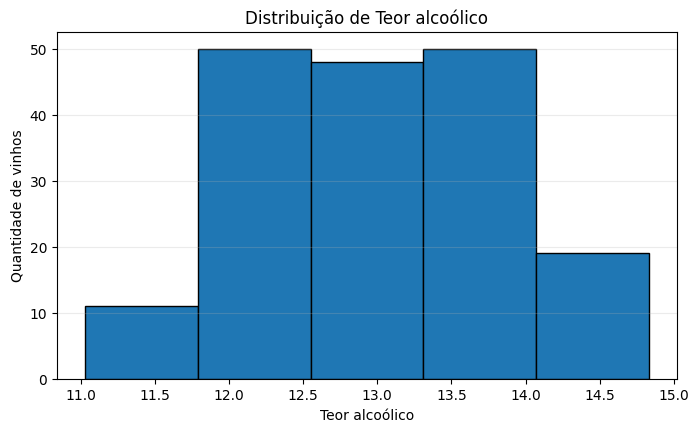

In [3]:
# Histograma com os mesmos limites da tabela de frequência
plt.figure(figsize=(8, 4.5))
plt.hist(df["Alcohol"], bins=limites, edgecolor="black")
plt.title("Distribuição de Teor alcoólico")
plt.xlabel("Teor alcoólico")
plt.ylabel("Quantidade de vinhos")
plt.grid(axis="y", alpha=0.25)
plt.show()


### 1.2 Análise descritiva

In [4]:
media = df["Alcohol"].mean()
mediana = df["Alcohol"].median()
moda = df["Alcohol"].mode().iloc[0]

minimo = df["Alcohol"].min()
maximo = df["Alcohol"].max()
amplitude = maximo - minimo
variancia = df["Alcohol"].var()
desvio_padrao = df["Alcohol"].std()

q1 = df["Alcohol"].quantile(0.25)
q2 = df["Alcohol"].quantile(0.50)
q3 = df["Alcohol"].quantile(0.75)
iqr = q3 - q1

print("Média:", round(media, 4))
print("Mediana:", round(mediana, 4))
print("Moda:", round(moda, 4))
print("Mínimo:", round(minimo, 4))
print("Máximo:", round(maximo, 4))
print("Amplitude:", round(amplitude, 4))
print("Variância:", round(variancia, 4))
print("Desvio padrão:", round(desvio_padrao, 4))
print("Q1:", round(q1, 4))
print("Q2 (mediana):", round(q2, 4))
print("Q3:", round(q3, 4))
print("IQR:", round(iqr, 4))



Média: 13.0006
Mediana: 13.05
Moda: 12.37
Mínimo: 11.03
Máximo: 14.83
Amplitude: 3.8
Variância: 0.6591
Desvio padrão: 0.8118
Q1: 12.3625
Q2 (mediana): 13.05
Q3: 13.6775
IQR: 1.315


**Interpretação:** média (13,00) e mediana (13,05) são muito próximas, e o desvio padrão de 0,81 indica a dispersão dos valores em torno da média.

### 1.3 Análise probabilística

In [5]:
total = len(df)


In [6]:
from scipy.stats import norm

# Probabilidade empírica: proporção de registros que atende a cada condição
cond1 = df["Alcohol"] >= 13
cond2 = df["Alcohol"] < 12.5

p1_emp = cond1.sum() / total
p2_emp = cond2.sum() / total

# Probabilidade pela distribuição normal, com a média e o desvio padrão de Alcohol
p1_normal = 1 - norm.cdf(13, media, desvio_padrao)
p2_normal = norm.cdf(12.5, media, desvio_padrao)

print("P(Alcohol >= 13) empírica =", round(p1_emp, 4), "=", round(p1_emp*100, 2), "%")
print("P(Alcohol < 12,5) empírica =", round(p2_emp, 4), "=", round(p2_emp*100, 2), "%")
print("P(Alcohol >= 13) normal =", round(p1_normal, 4), "=", round(p1_normal*100, 2), "%")
print("P(Alcohol < 12,5) normal =", round(p2_normal, 4), "=", round(p2_normal*100, 2), "%")



P(Alcohol >= 13) empírica = 0.5169 = 51.69 %
P(Alcohol < 12,5) empírica = 0.3202 = 32.02 %
P(Alcohol >= 13) normal = 0.5003 = 50.03 %
P(Alcohol < 12,5) normal = 0.2687 = 26.87 %


**Interpretação:** as probabilidades empíricas vêm dos próprios dados; as normais são uma aproximação. Para P(Alcohol ≥ 13) os valores são próximos (51,69% e 50,03%), mas para P(Alcohol < 12,5) a normal subestima a proporção observada (26,87% contra 32,02%).

## 2. Ácido málico (`Malic_Acid`)

### 2.1 Tabela de distribuição de frequências

In [7]:
# Intervalos e frequências (os mesmos limites são usados no histograma)
contagens_malic, limites_malic = np.histogram(df["Malic_Acid"], bins=5)
rotulos_malic = [f"{limites_malic[i]:.2f} a {limites_malic[i+1]:.2f}" for i in range(5)]
tabela_frequencia_malic = pd.DataFrame({
    "Intervalo": rotulos_malic,
    "Frequência": contagens_malic,
    "Frequência relativa (%)": (contagens_malic / len(df) * 100).round(2)
})

tabela_frequencia_malic


,Intervalo,Frequência,Frequência relativa (%)
0,0.74 a 1.75,77,43.26
1,1.75 a 2.76,49,27.53
2,2.76 a 3.78,25,14.04
3,3.78 a 4.79,21,11.80
4,4.79 a 5.80,6,3.37


**Interpretação:** 43,26% dos vinhos estão no primeiro intervalo e a frequência diminui nos seguintes, o que indica assimetria à direita.

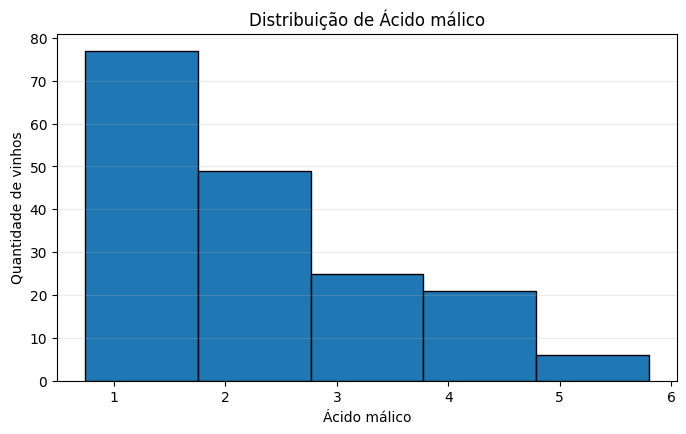

In [8]:
# Histograma com os mesmos limites da tabela de frequência
plt.figure(figsize=(8, 4.5))
plt.hist(df["Malic_Acid"], bins=limites_malic, edgecolor="black")
plt.title("Distribuição de Ácido málico")
plt.xlabel("Ácido málico")
plt.ylabel("Quantidade de vinhos")
plt.grid(axis="y", alpha=0.25)
plt.show()


### 2.2 Análise descritiva

In [9]:
media_malic = df["Malic_Acid"].mean()
mediana_malic = df["Malic_Acid"].median()
moda_malic = df["Malic_Acid"].mode().iloc[0]

minimo_malic = df["Malic_Acid"].min()
maximo_malic = df["Malic_Acid"].max()
amplitude_malic = maximo_malic - minimo_malic
variancia_malic = df["Malic_Acid"].var()
desvio_padrao_malic = df["Malic_Acid"].std()

q1_malic = df["Malic_Acid"].quantile(0.25)
q2_malic = df["Malic_Acid"].quantile(0.50)
q3_malic = df["Malic_Acid"].quantile(0.75)
iqr_malic = q3_malic - q1_malic

print("Média:", round(media_malic, 4))
print("Mediana:", round(mediana_malic, 4))
print("Moda:", round(moda_malic, 4))
print("Mínimo:", round(minimo_malic, 4))
print("Máximo:", round(maximo_malic, 4))
print("Amplitude:", round(amplitude_malic, 4))
print("Variância:", round(variancia_malic, 4))
print("Desvio padrão:", round(desvio_padrao_malic, 4))
print("Q1:", round(q1_malic, 4))
print("Q2 (mediana):", round(q2_malic, 4))
print("Q3:", round(q3_malic, 4))
print("IQR:", round(iqr_malic, 4))



Média: 2.3363
Mediana: 1.865
Moda: 1.73
Mínimo: 0.74
Máximo: 5.8
Amplitude: 5.06
Variância: 1.248
Desvio padrão: 1.1171
Q1: 1.6025
Q2 (mediana): 1.865
Q3: 3.0825
IQR: 1.48


**Interpretação:** a média (2,34) é maior que a mediana (1,87), o que reforça a cauda à direita. O desvio padrão de 1,12 mostra maior variação relativa que em Alcohol.

### 2.3 Análise probabilística

In [10]:
total = len(df)


In [11]:
# Probabilidade empírica: proporção de registros que atende a cada condição
cond1 = df["Malic_Acid"] <= 2
cond2 = df["Malic_Acid"] > 3

p1_emp_malic = cond1.sum() / total
p2_emp_malic = cond2.sum() / total

# Probabilidade pela distribuição normal, com a média e o desvio padrão de Malic_Acid
p1_normal_malic = norm.cdf(2, media_malic, desvio_padrao_malic)
p2_normal_malic = 1 - norm.cdf(3, media_malic, desvio_padrao_malic)

print("P(Malic_Acid <= 2) empírica =", round(p1_emp_malic, 4), "=", round(p1_emp_malic*100, 2), "%")
print("P(Malic_Acid > 3) empírica =", round(p2_emp_malic, 4), "=", round(p2_emp_malic*100, 2), "%")
print("P(Malic_Acid <= 2) normal =", round(p1_normal_malic, 4), "=", round(p1_normal_malic*100, 2), "%")
print("P(Malic_Acid > 3) normal =", round(p2_normal_malic, 4), "=", round(p2_normal_malic*100, 2), "%")



P(Malic_Acid <= 2) empírica = 0.5618 = 56.18 %
P(Malic_Acid > 3) empírica = 0.264 = 26.4 %
P(Malic_Acid <= 2) normal = 0.3817 = 38.17 %
P(Malic_Acid > 3) normal = 0.2762 = 27.62 %


**Interpretação:** para P(Malic_Acid > 3) a empírica (26,40%) e a normal (27,62%) são próximas. Para P(Malic_Acid ≤ 2) a normal fica bem abaixo da observada (38,17% contra 56,18%), porque a distribuição não é simétrica.

## Conclusão da Parte 1

**Alcohol:** os valores se concentram em torno de 13, com média de aproximadamente 13,00 e desvio padrão de 0,81. Média e mediana são próximas, o que indica uma distribuição aproximadamente simétrica.

**Malic_Acid:** a média foi de aproximadamente 2,34 e o desvio padrão de 1,12. A média maior que a mediana indica assimetria à direita.

Foram utilizadas medidas de tendência central, dispersão e quartis, além de tabelas e gráficos de frequência. Na parte probabilística, as probabilidades empíricas foram comparadas com as obtidas por uma distribuição normal.

# Parte 2 – Machine Learning & Modelling

## Agrupamento do dataset WINES com K-means

**Objetivo:** agrupar os vinhos mais similares entre si utilizando K-means, sem utilizar uma variável de classe como entrada do agrupamento.

**Problema:** identificar perfis de vinhos com características químicas semelhantes.

**Abordagem:** pré-processar os dados, testar diferentes valores de K com Elbow e Silhouette Score, aplicar o K-means e interpretar os grupos encontrados.

In [12]:
# Bibliotecas utilizadas na Parte 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

try:
    df_ml = pd.read_csv("wines.csv")
except FileNotFoundError:
    df_ml = pd.read_csv("wine-clustering.csv")

print(f"Dataset carregado: {df_ml.shape[0]} registros e {df_ml.shape[1]} colunas")
df_ml.head()

Dataset carregado: 178 registros e 13 colunas


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 1. Pré-processamento

Nesta etapa verificamos a existência de colunas de classe, a presença de dados nulos e a escala das variáveis. Primeiro identificamos possíveis colunas de classe e depois padronizamos as variáveis numéricas.

In [13]:
# Identifica uma possível coluna de classe (ela não deve entrar no K-means)
possiveis_classes = [c for c in df_ml.columns if c.lower() in ["class", "target", "classe"]]

if possiveis_classes:
    X_ml = df_ml.drop(columns=possiveis_classes).copy()
    print("Feature(s) de classe excluída(s):", possiveis_classes)
else:
    X_ml = df_ml.copy()
    print("Nenhuma feature de classe encontrada. Todas as variáveis disponíveis serão analisadas.")

# Mantém somente as variáveis quantitativas
X_ml = X_ml.select_dtypes(include=np.number).copy()

print("\nFeatures utilizadas no clustering:")
print(list(X_ml.columns))
print("Quantidade de features:", X_ml.shape[1])

Nenhuma feature de classe encontrada. Todas as variáveis disponíveis serão analisadas.

Features utilizadas no clustering:
['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']
Quantidade de features: 13


In [14]:
# Verificação e tratamento de dados nulos
print("Valores nulos por variável:")
print(X_ml.isnull().sum())

if X_ml.isnull().sum().sum() > 0:
    # Valores nulos são substituídos pela mediana da própria variável
    X_ml = X_ml.fillna(X_ml.median(numeric_only=True))
    print("\nValores nulos encontrados e preenchidos pela mediana.")
else:
    print("\nNão existem valores nulos; nenhum tratamento foi necessário.")

Valores nulos por variável:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Não existem valores nulos; nenhum tratamento foi necessário.


In [15]:
# Padronização (z-score): o K-means usa distância, então variáveis em escalas
# muito diferentes (como Proline) dominariam o cálculo sem esse ajuste.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ml)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_ml.columns)
print("Dados padronizados:")
X_scaled_df.head()

Dados padronizados:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### Resultado do pré-processamento

O dataset não possui coluna de classe nem valores nulos, então as 13 variáveis numéricas foram mantidas e padronizadas (z-score) antes do agrupamento.

## 2. Método Elbow

O método Elbow compara a inércia (WCSS) para diferentes valores de K. O K adequado é o ponto em que a redução da inércia passa a ser pequena.

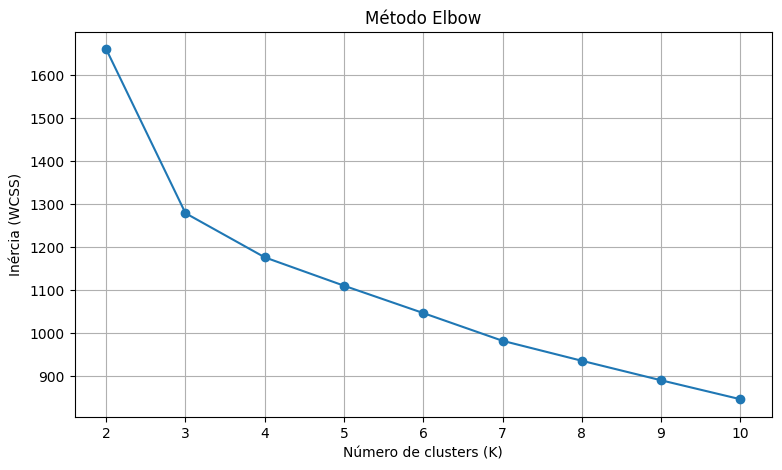

K=2: inércia=1658.76
K=3: inércia=1277.93
K=4: inércia=1175.43
K=5: inércia=1109.51
K=6: inércia=1046.00
K=7: inércia=981.60
K=8: inércia=935.20
K=9: inércia=889.89
K=10: inércia=845.90


In [16]:
# Teste de K de 2 a 10
ks = range(2, 11)
inertias = []

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)
    inertias.append(modelo.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia (WCSS)")
plt.title("Método Elbow")
plt.xticks(list(ks))
plt.grid(True)
plt.show()

for k, inertia in zip(ks, inertias):
    print(f"K={k}: inércia={inertia:.2f}")

## 3. Silhouette Score

O Silhouette Score mede o quanto os elementos estão próximos do próprio grupo e afastados dos demais. Quanto maior o valor, melhor a separação entre os clusters.

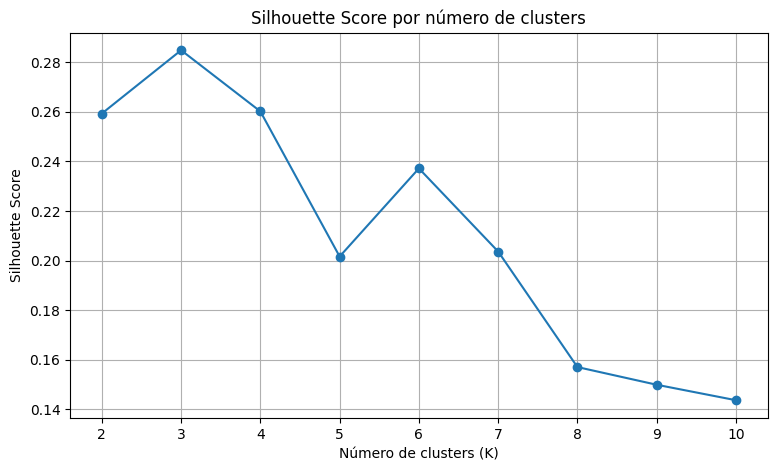

K=2: Silhouette Score=0.2593
K=3: Silhouette Score=0.2849
K=4: Silhouette Score=0.2602
K=5: Silhouette Score=0.2016
K=6: Silhouette Score=0.2372
K=7: Silhouette Score=0.2036
K=8: Silhouette Score=0.1570
K=9: Silhouette Score=0.1499
K=10: Silhouette Score=0.1436

Melhor K pelo Silhouette Score: 3


In [17]:
silhouette_scores = []

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = modelo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(list(ks), silhouette_scores, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")
plt.xticks(list(ks))
plt.grid(True)
plt.show()

for k, score in zip(ks, silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")

melhor_k_silhueta = list(ks)[int(np.argmax(silhouette_scores))]
print(f"\nMelhor K pelo Silhouette Score: {melhor_k_silhueta}")

### Escolha do K

O Silhouette Score é máximo em **K = 3** (0,2849). No Elbow, a maior queda de inércia ocorre de K=2 para K=3 (cerca de 381 pontos), enquanto de K=3 para K=4 a queda é de apenas cerca de 103. Por isso o modelo final utiliza **K = 3**.

In [18]:
# Ajuste final do K-means com K=3
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_ml_resultado = df_ml.copy()
df_ml_resultado["Cluster"] = clusters

print("K-means ajustado com K=3.")
print("\nQuantidade de vinhos por cluster:")
print(df_ml_resultado["Cluster"].value_counts().sort_index())

print("\nInércia do modelo final:", round(kmeans.inertia_, 2))
print("Silhouette Score do modelo final:", round(silhouette_score(X_scaled, clusters), 4))

K-means ajustado com K=3.

Quantidade de vinhos por cluster:
Cluster
0    65
1    51
2    62
Name: count, dtype: int64

Inércia do modelo final: 1277.93
Silhouette Score do modelo final: 0.2849


## 4. Visualização dos grupos

Como o dataset possui muitas variáveis, o PCA é usado apenas para representar os clusters em duas dimensões. O K-means foi ajustado com todas as variáveis padronizadas, e não com os componentes principais.

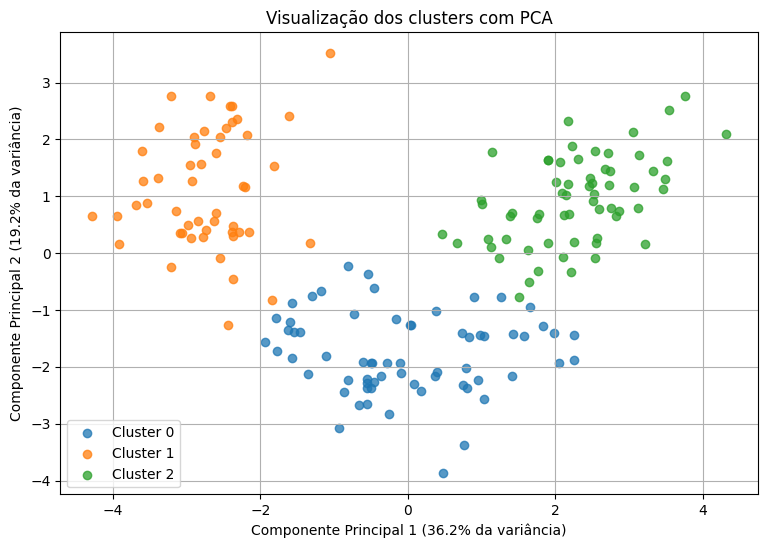

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
for cluster in sorted(np.unique(clusters)):
    mask = clusters == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {cluster}", alpha=0.75)

plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} da variância)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} da variância)")
plt.title("Visualização dos clusters com PCA")
plt.legend()
plt.grid(True)
plt.show()

## 5. Análise dos grupos e características dos vinhos

Comparamos as médias das variáveis em cada cluster, com destaque para o **teor alcoólico** e a **acidez (ácido málico)**.

In [20]:
# Média de cada característica por cluster
media_clusters = df_ml_resultado.groupby("Cluster")[X_ml.columns].mean()
print("Média das características por cluster:")
display(media_clusters.round(2))

Média das características por cluster:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


In [21]:
# Teor alcoólico médio por cluster
media_alcohol = media_clusters["Alcohol"].sort_values(ascending=False)
print("Teor alcoólico médio por cluster:")
print(media_alcohol.round(2))
print(f"\nCluster com maior teor alcoólico médio: {media_alcohol.idxmax()}")
print(f"Cluster com menor teor alcoólico médio: {media_alcohol.idxmin()}")

Teor alcoólico médio por cluster:
Cluster
2    13.68
1    13.13
0    12.25
Name: Alcohol, dtype: float64

Cluster com maior teor alcoólico médio: 2
Cluster com menor teor alcoólico médio: 0


In [22]:
# Ácido málico médio por cluster
media_malic = media_clusters["Malic_Acid"].sort_values(ascending=False)
print("Ácido málico médio por cluster:")
print(media_malic.round(2))
print(f"\nCluster com maior valor médio de ácido málico: {media_malic.idxmax()}")
print(f"Cluster com menor valor médio de ácido málico: {media_malic.idxmin()}")

Ácido málico médio por cluster:
Cluster
1    3.31
2    2.00
0    1.90
Name: Malic_Acid, dtype: float64

Cluster com maior valor médio de ácido málico: 1
Cluster com menor valor médio de ácido málico: 0


In [23]:
# Características que mais diferenciam cada cluster.
# Usamos a média padronizada (z-score) de cada cluster, que deixa todas as variáveis
# na mesma escala; valores positivos estão acima da média geral e negativos abaixo.
media_padronizada = X_scaled_df.groupby(clusters).mean()

for cluster in sorted(media_padronizada.index):
    diferencas = media_padronizada.loc[cluster].abs().sort_values(ascending=False)
    print(f"\n--- Cluster {cluster} ---")
    print("Quantidade de vinhos:", int((clusters == cluster).sum()))
    print("Características que mais diferenciam o grupo (média padronizada):")
    print(media_padronizada.loc[cluster, diferencas.head(5).index].round(2))


--- Cluster 0 ---
Quantidade de vinhos: 65
Características que mais diferenciam o grupo (média padronizada):
Alcohol           -0.93
Color_Intensity   -0.90
Proline           -0.75
Ash               -0.49
Magnesium         -0.49
Name: 0, dtype: float64

--- Cluster 1 ---
Quantidade de vinhos: 51
Características que mais diferenciam o grupo (média padronizada):
OD280             -1.29
Flavanoids        -1.22
Hue               -1.16
Total_Phenols     -0.98
Color_Intensity    0.94
Name: 1, dtype: float64

--- Cluster 2 ---
Quantidade de vinhos: 62
Características que mais diferenciam o grupo (média padronizada):
Proline          1.13
Flavanoids       0.98
Total_Phenols    0.89
Alcohol          0.84
OD280            0.78
Name: 2, dtype: float64


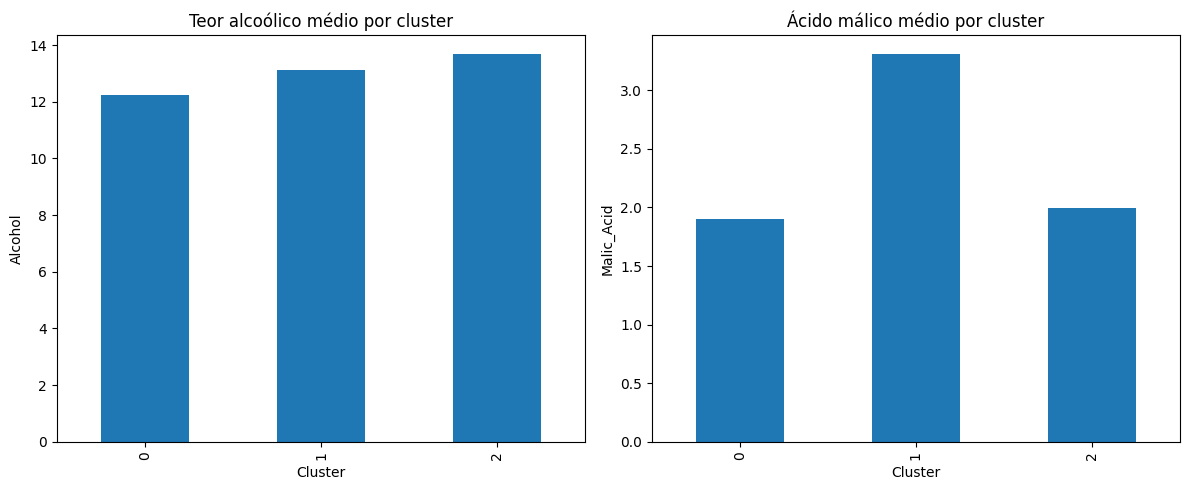

In [24]:
# Comparação de Alcohol e Malic_Acid entre os clusters
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

media_clusters["Alcohol"].plot(kind="bar", ax=axes[0], title="Teor alcoólico médio por cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Alcohol")

media_clusters["Malic_Acid"].plot(kind="bar", ax=axes[1], title="Ácido málico médio por cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Malic_Acid")

plt.tight_layout()
plt.show()

## 6. Conclusão da Parte 2

O K-means agrupou os vinhos de acordo com suas características químicas. O dataset não possui coluna de classe nem valores nulos, e as 13 variáveis foram padronizadas antes do agrupamento.

Os métodos Elbow e Silhouette indicaram K=3, que foi usado no modelo final (clusters com 65, 51 e 62 vinhos; Silhouette Score de 0,2849).

- **Teor alcoólico:** o cluster 2 tem a maior média (13,68) e o cluster 0 a menor (12,25).
- **Ácido málico:** o cluster 1 tem a maior média (3,31) e o cluster 0 a menor (1,90).

Pela média padronizada, os grupos se diferenciam principalmente por:

- **Cluster 0:** teor alcoólico, intensidade de cor e prolina abaixo da média.
- **Cluster 1:** OD280, flavonoides, matiz (Hue) e fenóis totais baixos, com intensidade de cor alta.
- **Cluster 2:** prolina, flavonoides, fenóis totais, teor alcoólico e OD280 acima da média.

Assim, o cluster 0 reúne vinhos com menor teor alcoólico e menor acidez, o cluster 1 vinhos mais ácidos e o cluster 2 vinhos mais alcoólicos e com maior teor de prolina. Os clusters representam perfis químicos distintos, obtidos sem usar uma classe como entrada.